Group member 1: Viola, Bätz 

Group member 2: Leonard, Batten-Wölfl 

Group member 3: Zeynep Dakduklu

---

In [3]:
import pandas as pd
import numpy as np
import geopandas as gpd

import matplotlib.pyplot as plt 
import seaborn as sns
import contextily as cx

!pip install jinja2 --break-system-packages

gdf = gpd.read_file("airbnb_listings.geojson")
gdf.head()

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.9/134.9 kB 13.7 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


,accommodates,bathrooms,bedrooms,beds,rt_Private_room,rt_Shared_room,pg_Condominium,pg_House,pg_Other,pg_Townhouse,price,geometry
0,5,2.0,2.0,2.0,0,0,0,1,0,0,425.0,POINT (-117.12971 32.75399)
1,6,1.0,2.0,4.0,0,0,1,0,0,0,205.0,POINT (-117.25253 32.78421)
2,2,1.0,1.0,1.0,1,0,0,0,0,0,99.0,POINT (-117.14121 32.75327)
3,2,1.0,1.0,1.0,1,0,0,1,0,0,72.0,POINT (-117.15269 32.93110)
4,2,1.0,1.0,1.0,1,0,0,1,0,0,55.0,POINT (-117.21870 32.74202)


Der Datensatz beinhaltet 6110 AirBnB Listings in San Diego. Jede Zeile repräsentiert ein Listing und beinhaltet Informationen über Gebäudetyp, Zimmertyp, Lage und Preis.

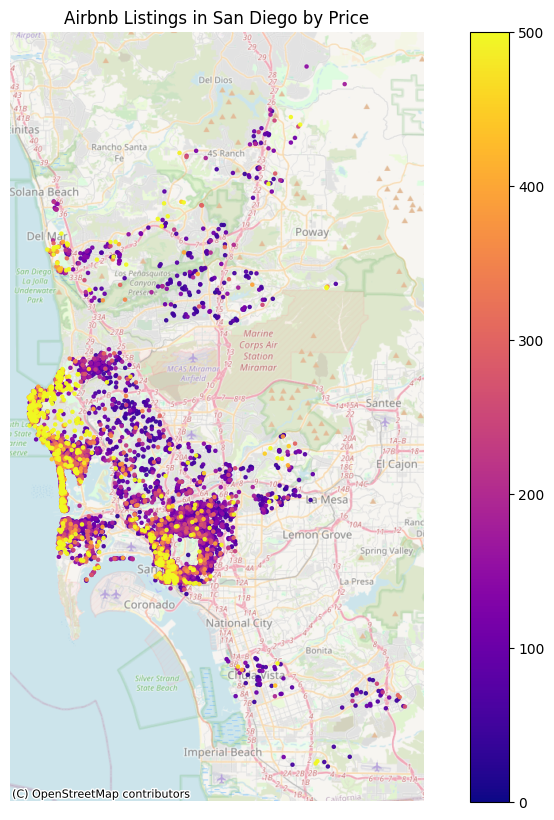

In [4]:
gdf_web = gdf.to_crs(epsg=3857)

gdf_web = gdf_web.sort_values("price", ascending=True)

fig, ax = plt.subplots(figsize=(12, 10))

gdf_web.plot(
    column="price",
    ax=ax,
    legend=True,
    cmap="plasma",
    markersize=5,
    alpha=0.9,
    zorder=2,
    vmin=0,
    vmax=500
)

cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik, alpha=0.6)

ax.set_axis_off()

plt.title("Airbnb Listings in San Diego by Price")
plt.show()

Auf der Karte ist deutlich zu erkennen, dass es Gebiete gibt, in denen die Preise und die Dichte an Airbnbs höher sind als in anderen. Daraus lässt sich bereits schließen, dass Aufenthalte in Küstennähe beliebter sind als im Landesinneren.

In [5]:
variable_names = [
    "accommodates", "bathrooms", "bedrooms", "beds",
    "rt_Private_room", "rt_Shared_room",
    "pg_Condominium", "pg_House", "pg_Other", "pg_Townhouse"
]

numerische_vars = ["accommodates", "bathrooms", "bedrooms", "beds"]
binaere_vars = ["rt_Private_room", "rt_Shared_room",
                "pg_Condominium", "pg_House", "pg_Other", "pg_Townhouse"]


print("=== Deskriptive Statistiken ===")
gdf[numerische_vars + ["price"]].describe().round(2)

=== Deskriptive Statistiken ===


,accommodates,bathrooms,bedrooms,beds,price
count,6110.00,6110.00,6110.00,6110.00,6110.00
mean,4.22,1.48,1.59,2.20,215.97
std,2.84,0.86,1.14,1.71,277.55
min,1.00,0.00,0.00,0.00,18.00
25%,2.00,1.00,1.00,1.00,85.00
50%,4.00,1.00,1.00,2.00,139.00
75%,6.00,2.00,2.00,3.00,250.00
max,21.00,10.00,10.00,16.00,4900.00


Der durchschnittliche Übernachtungspreis beträgt 215,97$, der Median liegt bei 139,00$. Dies deutet darauf hin, dass einige wenige sehr teure Angebote die Verteilung nach oben verzerren. Die Variable **accomodates** reicht von 1 bis 21 Personen, mit einem Median von 4. Einige Angebote weisen verdächtige Werte auf, beispielsweise maximal 10 Badezimmer – dies könnte auf Dateneingabefehler hindeuten und sollte bei der Modellierung sorgfältig berücksichtigt werden.

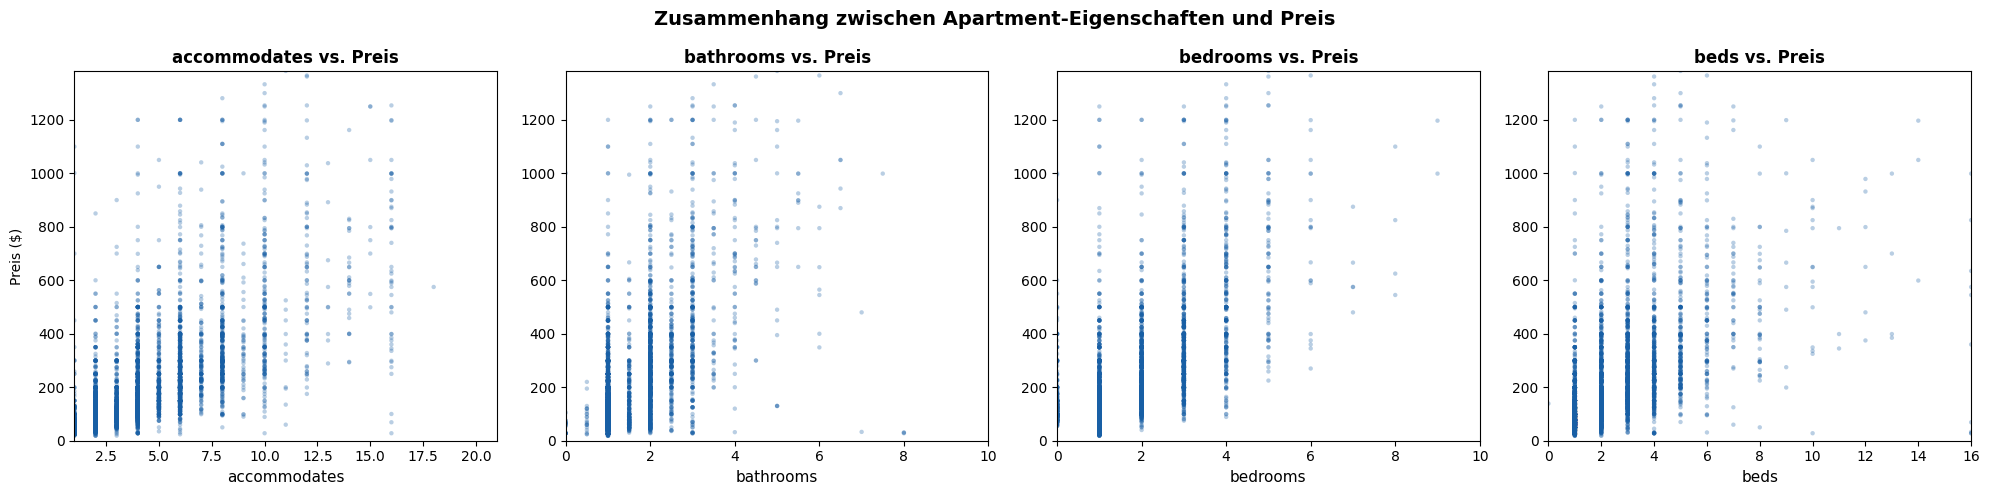

In [6]:

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, var in zip(axes, numerische_vars):
    ax.scatter(
        gdf[var],
        gdf["price"],
        alpha=0.3,
        s=10,
        color="#185FA5",
        edgecolors="none"
    )
    
    ax.set_xlabel(var, fontsize=11)
    ax.set_ylabel("Preis ($)" if var == numerische_vars[0] else "")
    ax.set_title(f"{var} vs. Preis", fontsize=12, fontweight="bold")
    ax.set_xlim(gdf[var].min(), gdf[var].max())
    ax.set_ylim(0, gdf["price"].quantile(0.99))  # Ausreißer oben abschneiden

plt.suptitle("Zusammenhang zwischen Apartment-Eigenschaften und Preis",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Die Streudiagramme zeigen einen positiven Zusammenhang zwischen dem Preis und der Anzahl der Personen, die eine Unterkunft beherbergen kann, sowie der Anzahl der Schlafzimmer und Betten. Unterkünfte mit mehr Schlafzimmern erzielen erwartungsgemäß höhere Preise. Der Zusammenhang ist jedoch nicht perfekt linear – es gibt eine beträchtliche Streuung, insbesondere bei höheren Werten, was darauf hindeutet, dass auch andere Faktoren die Preisgestaltung beeinflussen.

In [7]:
keine_zimmertyp = ((gdf["rt_Private_room"] == 0) & (gdf["rt_Shared_room"] == 0)).sum()

zimmer_labels = {
    "rt_Private_room": "Privatzimmer",
    "rt_Shared_room":  "Gemeinschaftszimmer",
}
zimmer_vars = ["rt_Private_room", "rt_Shared_room"]

summary_zimmer = pd.DataFrame({
    "Zimmertyp": [zimmer_labels[var] for var in zimmer_vars] + ["Keine Angabe"],
    "Anzahl":    [int(gdf[var].sum()) for var in zimmer_vars] + [int(keine_zimmertyp)],
    "Anteil (%)": [(gdf[var].sum() / len(gdf) * 100).round(1) for var in zimmer_vars] + [round(keine_zimmertyp / len(gdf) * 100, 1)],
})

display(summary_zimmer.style \
    .set_caption("Zimmertyp der AirBnB-Listings") \
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold"), ("text-align", "left"), ("padding-bottom", "8px")]},
        {"selector": "th", "props": [("background-color", "#E6F1FB"), ("color", "#0C447C"), ("font-weight", "500"), ("padding", "8px 16px")]},
        {"selector": "td", "props": [("padding", "7px 16px"), ("border-bottom", "0.5px solid #D3D1C7")]},
        {"selector": "tr:hover td", "props": [("background-color", "#F1EFE8")]},
    ]) \
    .hide(axis="index") \
    .format({"Anteil (%)": "{:.1f}%"}))

# ── Gebäudetyp ────────────────────────────────────────────────────────────────
keine_gebaeude = ((gdf["pg_Condominium"] == 0) & (gdf["pg_House"] == 0) &
                  (gdf["pg_Townhouse"] == 0) & (gdf["pg_Other"] == 0)).sum()

gebaeude_labels = {
    "pg_Condominium": "Eigentumswohnung",
    "pg_House":       "Haus",
    "pg_Townhouse":   "Reihenhaus",
    "pg_Other":       "Sonstiges",
}
gebaeude_vars = ["pg_Condominium", "pg_House", "pg_Townhouse", "pg_Other"]

summary_gebaeude = pd.DataFrame({
    "Gebäudetyp": [gebaeude_labels[var] for var in gebaeude_vars] + ["Keine Angabe"],
    "Anzahl":     [int(gdf[var].sum()) for var in gebaeude_vars] + [int(keine_gebaeude)],
    "Anteil (%)": [(gdf[var].sum() / len(gdf) * 100).round(1) for var in gebaeude_vars] + [round(keine_gebaeude / len(gdf) * 100, 1)],
})

display(summary_gebaeude.style \
    .set_caption("Gebäudetyp der AirBnB-Listings") \
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold"), ("text-align", "left"), ("padding-bottom", "8px")]},
        {"selector": "th", "props": [("background-color", "#E6F1FB"), ("color", "#0C447C"), ("font-weight", "500"), ("padding", "8px 16px")]},
        {"selector": "td", "props": [("padding", "7px 16px"), ("border-bottom", "0.5px solid #D3D1C7")]},
        {"selector": "tr:hover td", "props": [("background-color", "#F1EFE8")]},
    ]) \
    .hide(axis="index") \
    .format({"Anteil (%)": "{:.1f}%"}))

Zimmertyp,Anzahl,Anteil (%)
Privatzimmer,1823,29.8%
Gemeinschaftszimmer,171,2.8%
Keine Angabe,4116,67.4%


Gebäudetyp,Anzahl,Anteil (%)
Eigentumswohnung,556,9.1%
Haus,2575,42.1%
Reihenhaus,207,3.4%
Sonstiges,533,8.7%
Keine Angabe,2239,36.6%


Zum Zimmertyp stellt die Mehrheit der Listings keine Angabe bereit. Man könnte vermuten, dass es nicht für nötig gehalten wurde dazu extra eine Angabe zu machen, was darauf schließen lässt, dass es sich hier nicht um Gemeinschaftszimmer handelt. Sicher können wir davon jedoch nicht ausgehen, weshalb wir im Folgenden zwar zunächst einmal die gesamte Verteilung betrachten werden, uns anschließend jedoch auf die AirBnBs mit Angabe beschränken. 
Ähnliches gilt für die Gebäudetypen, wobei man hier schlecht Rückschlüsse ziehen kann, wie es zum Fehlen der Angaben kommt. 

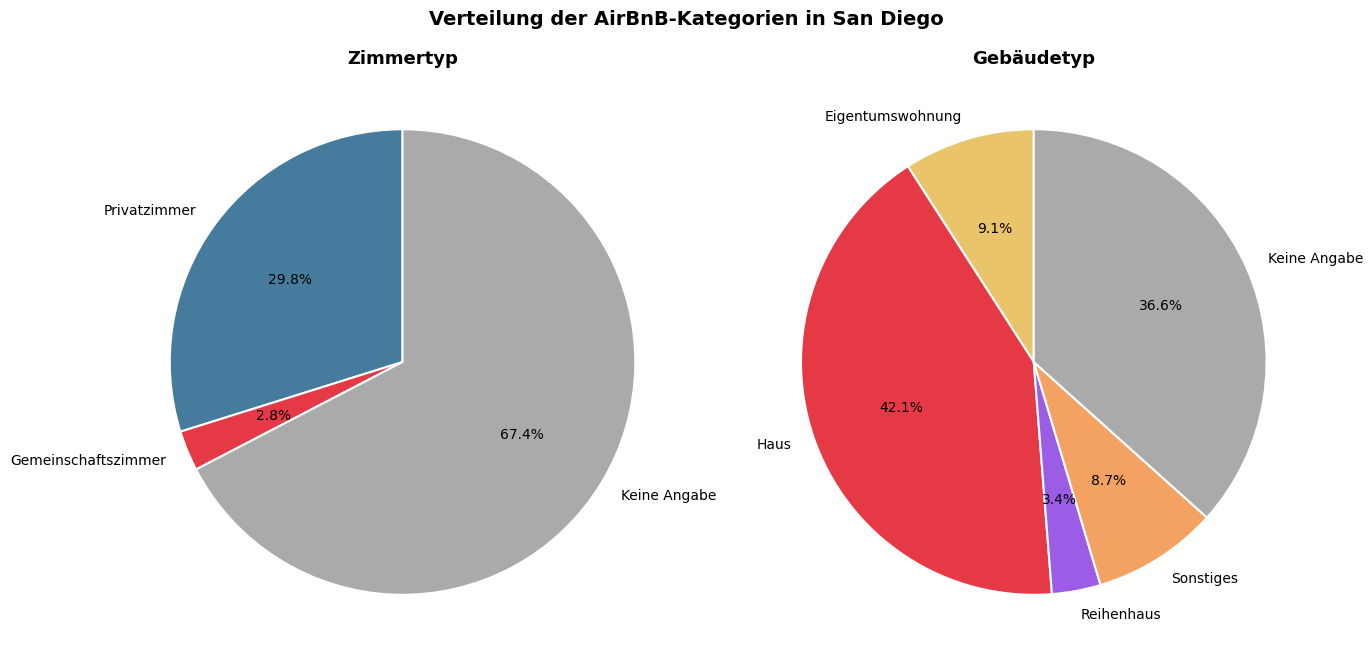

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

room_counts = {
    "Privatzimmer":        gdf["rt_Private_room"].sum(),
    "Gemeinschaftszimmer": gdf["rt_Shared_room"].sum(),
    "Keine Angabe":        keine_zimmertyp,
}
axes[0].pie(
    room_counts.values(),
    labels=room_counts.keys(),
    autopct="%1.1f%%",
    colors=["#457B9D", "#E63946", "#AAAAAA"],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
axes[0].set_title("Zimmertyp", fontsize=13, fontweight="bold")

prop_counts = {
    "Eigentumswohnung": gdf["pg_Condominium"].sum(),
    "Haus":             gdf["pg_House"].sum(),
    "Reihenhaus":       gdf["pg_Townhouse"].sum(),
    "Sonstiges":        gdf["pg_Other"].sum(),
    "Keine Angabe":     keine_gebaeude,
}
axes[1].pie(
    prop_counts.values(),
    labels=prop_counts.keys(),
    autopct="%1.1f%%",
    colors=["#E9C46A", "#E63946", "#9B5DE5", "#F4A261", "#AAAAAA"],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
axes[1].set_title("Gebäudetyp", fontsize=13, fontweight="bold")

plt.suptitle("Verteilung der AirBnB-Kategorien in San Diego", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Text(0.5, 0.98, 'Verteilung der AirBnB-Kategorien (nur Listings mit Angabe)')

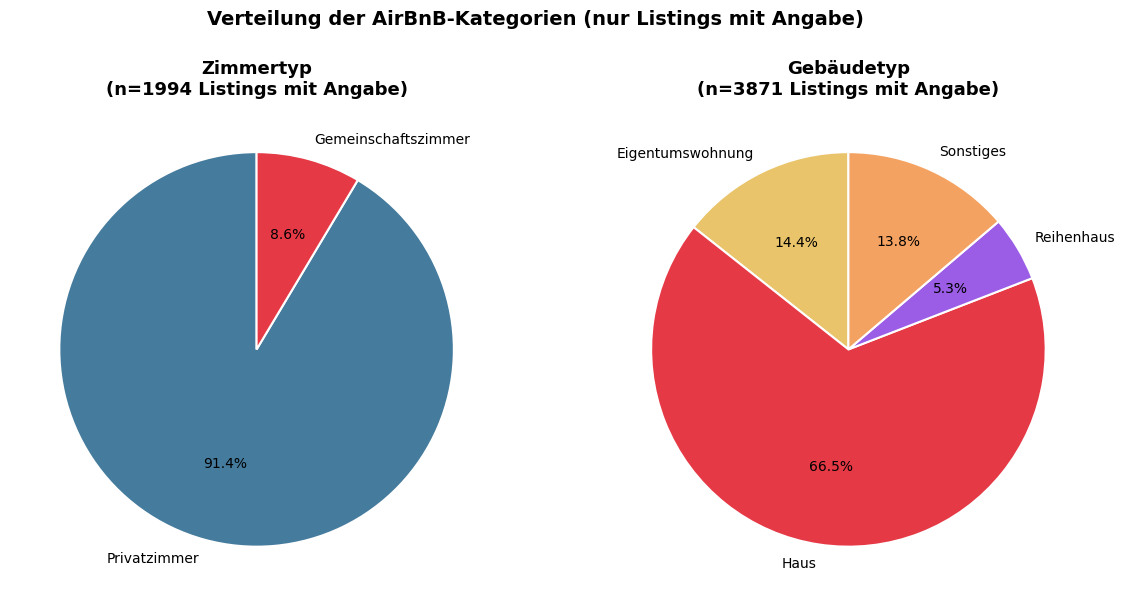

In [9]:
# ── Kreisdiagramme ohne "Keine Angabe" ───────────────────────────────────────

# Anzahl der AirBnBs mit Angabe
n_zimmer = len(gdf[gdf["rt_Private_room"] == 1]) + len(gdf[gdf["rt_Shared_room"] == 1])
n_gebaeude = int(gdf["pg_Condominium"].sum() + gdf["pg_House"].sum() + 
                 gdf["pg_Townhouse"].sum() + gdf["pg_Other"].sum())

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# ── Zimmertyp ─────────────────────────────────────────────────────────────────
room_counts = {
    "Privatzimmer":        gdf["rt_Private_room"].sum(),
    "Gemeinschaftszimmer": gdf["rt_Shared_room"].sum(),
}
axes[0].pie(
    room_counts.values(),
    labels=room_counts.keys(),
    autopct="%1.1f%%",
    colors=["#457B9D", "#E63946"],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
axes[0].set_title(f"Zimmertyp\n(n={n_zimmer} Listings mit Angabe)", 
                  fontsize=13, fontweight="bold")

# ── Gebäudetyp ────────────────────────────────────────────────────────────────
prop_counts = {
    "Eigentumswohnung": gdf["pg_Condominium"].sum(),
    "Haus":             gdf["pg_House"].sum(),
    "Reihenhaus":       gdf["pg_Townhouse"].sum(),
    "Sonstiges":        gdf["pg_Other"].sum(),
}
axes[1].pie(
    prop_counts.values(),
    labels=prop_counts.keys(),
    autopct="%1.1f%%",
    colors=["#E9C46A", "#E63946", "#9B5DE5", "#F4A261"],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
axes[1].set_title(f"Gebäudetyp\n(n={n_gebaeude} Listings mit Angabe)", 
                  fontsize=13, fontweight="bold")

plt.suptitle("Verteilung der AirBnB-Kategorien (nur Listings mit Angabe)", 
             fontsize=14, fontweight="bold")

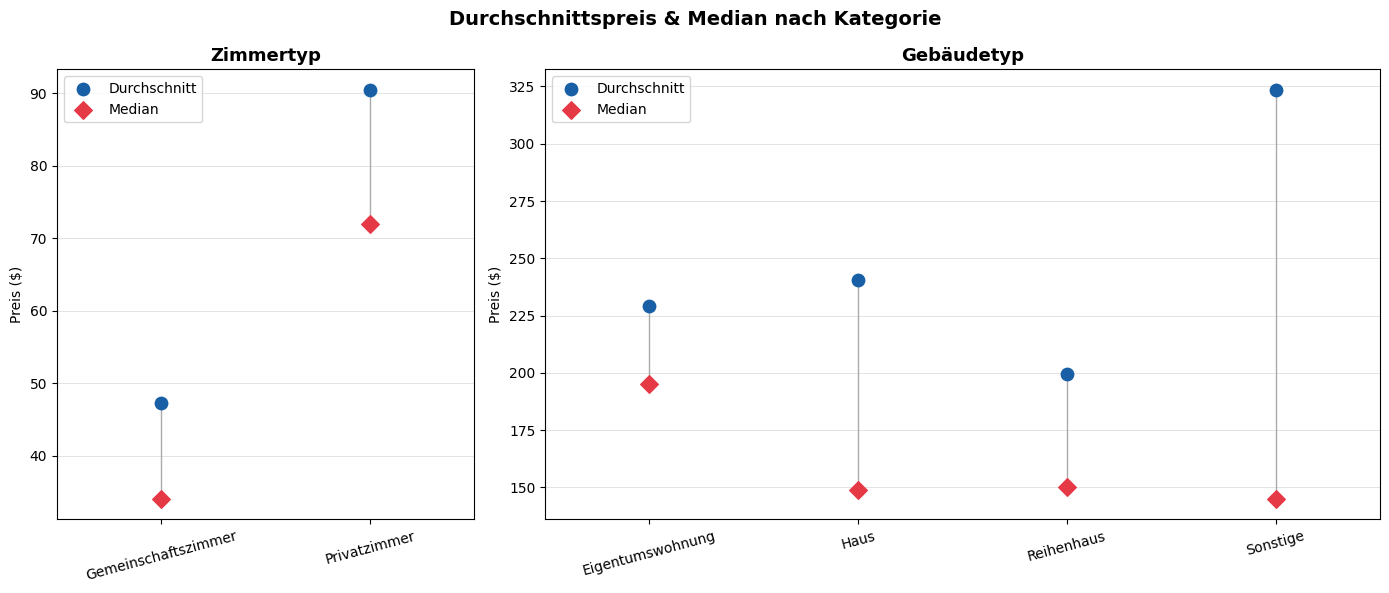

In [10]:
# ── Durchschnittspreis & Median nach Zimmertyp und Gebäudetyp ─────────────────

# ── Zimmertyp ─────────────────────────────────────────────────────────────────
gdf["Zimmertyp"] = "Keine Angabe"
gdf.loc[gdf["rt_Private_room"] == 1, "Zimmertyp"] = "Privatzimmer"
gdf.loc[gdf["rt_Shared_room"] == 1, "Zimmertyp"] = "Gemeinschaftszimmer"

zimmer_stats = gdf.groupby("Zimmertyp")["price"].agg(["mean", "median"]).round(2)
zimmer_stats = zimmer_stats.drop("Keine Angabe", errors="ignore")


# ── Gebäudetyp ────────────────────────────────────────────────────────────────
gdf["Gebäudetyp"] = "Keine Angabe"
gdf.loc[gdf["pg_Condominium"] == 1, "Gebäudetyp"] = "Eigentumswohnung"
gdf.loc[gdf["pg_House"] == 1, "Gebäudetyp"]       = "Haus"
gdf.loc[gdf["pg_Townhouse"] == 1, "Gebäudetyp"]   = "Reihenhaus"
gdf.loc[gdf["pg_Other"] == 1, "Gebäudetyp"]       = "Sonstige"

gebaeude_stats = gdf.groupby("Gebäudetyp")["price"].agg(["mean", "median"]).round(2)
gebaeude_stats = gebaeude_stats.drop("Keine Angabe", errors="ignore")

# ── Plot ──────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"width_ratios": [1, 2]})
for ax, stats, titel in zip(axes, 
                              [zimmer_stats, gebaeude_stats], 
                              ["Zimmertyp", "Gebäudetyp"]):
    ax.scatter(stats.index, stats["mean"],   
               color="#185FA5", s=80, zorder=3, label="Durchschnitt")
    ax.scatter(stats.index, stats["median"], 
               color="#E63946", s=80, zorder=3, label="Median", marker="D")
    
    for kategorie in stats.index:
        ax.plot([kategorie, kategorie], 
                [stats.loc[kategorie, "median"], stats.loc[kategorie, "mean"]],
                color="#AAAAAA", linewidth=1, zorder=2)
    
    ax.set_title(titel, fontsize=13, fontweight="bold")
    ax.set_ylabel("Preis ($)")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)
    ax.legend()
    ax.grid(axis="y", linewidth=0.5, alpha=0.5)
    ax.set_xlim(-0.5, len(stats.index) - 0.5)

plt.suptitle("Durchschnittspreis & Median nach Kategorie", 
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Zimmertyp:  
Mit Sicherheit lässt sich sagen, dass der Zimmertyp einen starken Einfluss auf die Bepreisung hat, denn Privatzimmer können offenbar zu einem deutlich höheren Preis angeboten werden. Wahrscheinlich lässt sich damit die geringe Anzahl an Gemeinschaftszimmern erklären.

Gebäudetyp:  
Da durch die starke Abweichung von Median und Durchschnitt nicht wirklich eine Aussage zur Beeinflussung des Preises getroffen werden kann ist hier vor allem gerade diese Abweichung interessant. Die Kategorie **Sonstige** scheint breit aufgestellt zu sein, wahrscheinlich beinhaltet sie teure Villen, aber auch günstige Unterkünfte. Hier können wir aber nur Vermutungen anstellen, weshalb wir uns bei weiterer Betrachtung auf die anderen drei Kategorien beschränken. Offenbar gibt es bei jedem Gebäudetyp, aber vor allem bei den Häusern, einige wenige Unterkünfte, die den Durchschnitt durch besonders hohe Bepreisung nach oben ziehen. Betrachtet man den Median, so fällt auf, dass für die Eigentumswohnungen die höchste Miete verlangt werden kann. Möglicherweise hängt das mit der Lage zusammen, denn im Stadtzentrum sind wahrscheinlich weniger Häuser oder Reihenhäuser, sondern hauptsächlich Wohnungen zu finden und wie wir oben bereits festgestellt haben sind AirBnBs mit zentraler Lage in Küstennähe deutlich teurer.

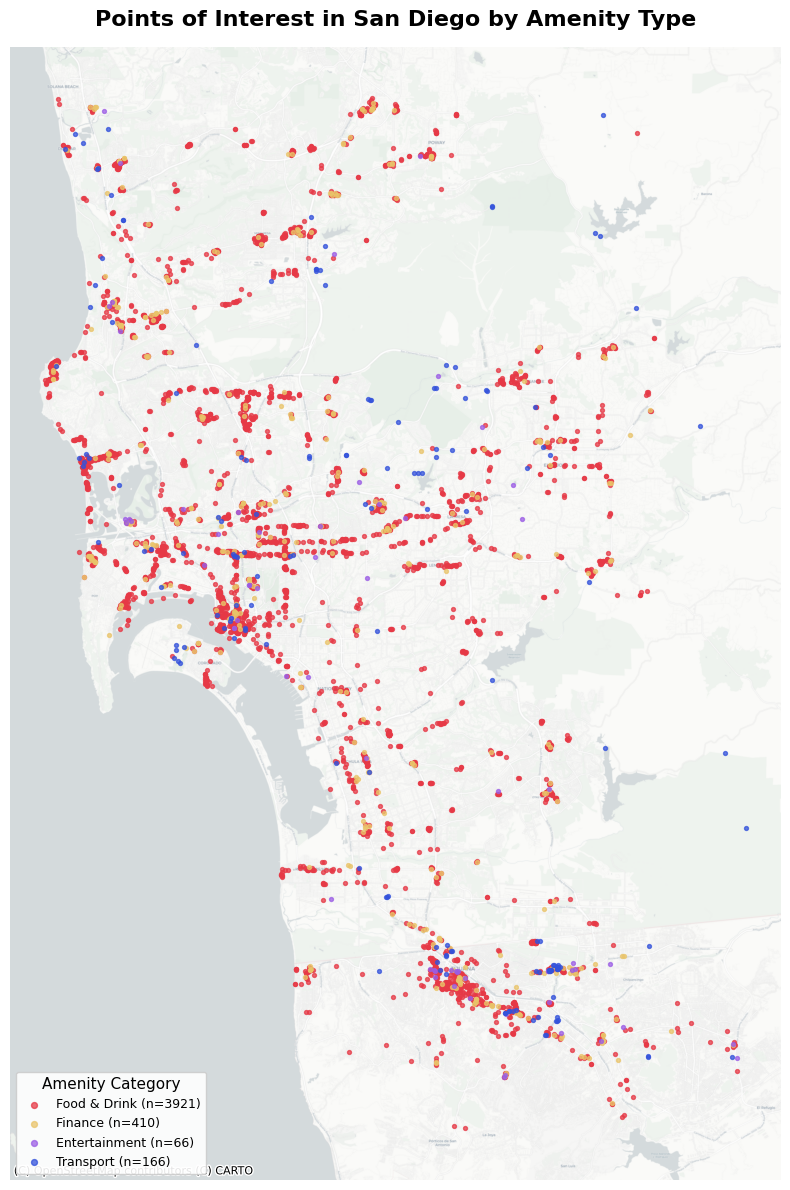


Total POIs plotted: 4563
group
Food & Drink     3921
Finance           410
Transport         166
Entertainment      66


In [11]:
import osmnx as ox
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import contextily as ctx
import geopandas as gpd

# ── 1. Re-download POIs for San Diego ────────────────────────────────────────
address = "San Diego, California, USA"

pois = ox.features_from_address(
    address,
    tags={"amenity": [
        "restaurant", "cafe", "bar", "pub", "fast_food",
        "bank", "atm",
        "cinema", "theatre",
        "parking", "bus_station",
    ]},
    dist=30000  # 3 km radius — wider for San Diego's spread-out layout
)

# ── 2. Clean POI data ─────────────────────────────────────────────────────────
pois.reset_index(inplace=True)
pois = pois[pois.element_type == "node"]

# ── 3. Define amenity groups + color mapping ──────────────────────────────────
amenity_groups = {
    "Food & Drink":     (["restaurant", "cafe", "bar", "pub", "fast_food"],  "#E63946"),
    "Finance":          (["bank", "atm"],                                     "#E9C46A"),
    "Entertainment":    (["cinema", "theatre"],                               "#9B5DE5"),
    "Transport":        (["parking", "bus_station"],                          "#3352DB"),
}

# Map each amenity value → group color
amenity_to_color = {}
amenity_to_group = {}
for group, (amenities, color) in amenity_groups.items():
    for a in amenities:
        amenity_to_color[a] = color
        amenity_to_group[a] = group

pois["color"] = pois["amenity"].map(amenity_to_color).fillna("#AAAAAA")
pois["group"] = pois["amenity"].map(amenity_to_group).fillna("Other")

# ── 4. Reproject to Web Mercator for contextily basemap ───────────────────────
pois_wm = pois.to_crs(epsg=3857)

# ── 5. Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 12))

# Plot each group separately so legend is clean
for group, (amenities, color) in amenity_groups.items():
    subset = pois_wm[pois_wm["group"] == group]
    if not subset.empty:
        subset.plot(
            ax=ax,
            color=color,
            markersize=8,
            alpha=0.75,
            zorder=3,
            label=f"{group} (n={len(subset)})"
        )

# Add "Other" amenities if any slipped through
other = pois_wm[pois_wm["group"] == "Other"]
if not other.empty:
    other.plot(ax=ax, color="#AAAAAA", markersize=5, alpha=0.5, zorder=2, label=f"Other (n={len(other)})")

# ── 6. Add basemap ────────────────────────────────────────────────────────────
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,  # clean light basemap
    zoom=13
)

# ── 7. Style the map ──────────────────────────────────────────────────────────
ax.set_title("Points of Interest in San Diego by Amenity Type", fontsize=16, fontweight="bold", pad=15)
ax.set_axis_off()

legend = ax.legend(
    title="Amenity Category",
    title_fontsize=11,
    fontsize=9,
    loc="lower left",
    framealpha=0.9,
    edgecolor="#CCCCCC",
    markerscale=1.5
)

plt.tight_layout()
plt.savefig("san_diego_pois.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nTotal POIs plotted: {len(pois_wm)}")
print(pois.groupby("group").size().sort_values(ascending=False).to_string())

Mit diesem Code beginnen wir, die Datenbasis aufzubauen, die wir später für das Machine Learning benötigen. Wir verwenden zunächst osmnx, um aus OpenStreetMap innerhalb eines Radius von 30 km alle Restaurants, Banken/ATMs, Kinos/Theater sowie Busstationen und Parkplätze zu finden. Diese Daten speichern wir und fassen sie anschließend in Gruppen zusammen. Danach konvertieren wir die Daten in das Web-Mercator-Format und nutzen dieses, um die Karte zu erstellen.

Schließlich erstellen wir noch eine Legende und verfassen eine Zusammenfassung.

In [12]:
import pandas as pd
import numpy as np
import geopandas as gpd
from scipy.stats import gaussian_kde

# ── 1. Load Airbnb & Match CRS ────────────────────────────────────────────────
airbnb = gpd.read_file("airbnb_listings.geojson").to_crs(pois.crs)
print(f"Airbnb loaded & reprojected: {airbnb.shape}, CRS: {airbnb.crs}")

# ── 2. Get Airbnb Coordinates Vectorized ──────────────────────────────────────
# Ersetzt die komplizierte create_coordinate_array Funktion
airbnb_xy = np.vstack([airbnb.geometry.x, airbnb.geometry.y])

# ── 3. KDE for Airbnb listings ────────────────────────────────────────────────
airbnb["kde_airbnb"] = gaussian_kde(airbnb_xy)(airbnb_xy)
print("Airbnb KDE added.")

# ── 4. KDE for each POI amenity type (using groupby for cleaner loop) ─────────
print(f"Computing KDE for amenity types...")

for amenity, subset in pois.groupby("amenity"):
    # Mindestens 2 Punkte nötig und wir skippen leere oder unbrauchbare Subsets
    if len(subset) < 2:
        airbnb[f"kde_{amenity}"] = np.nan
        continue

    poi_xy = np.vstack([subset.geometry.x, subset.geometry.y])
    
    try:
        # Berechne KDE direkt und weise sie zu
        airbnb[f"kde_{amenity}"] = gaussian_kde(poi_xy)(airbnb_xy)
        print(f"  ✓ kde_{amenity} added (n={len(subset)} POIs)")
    except Exception as e:
        # Fängt lineare Abhängigkeiten (collinear) und andere Fehler automatisch ab
        print(f"  Skipping '{amenity}' - KDE failed: {e}")
        airbnb[f"kde_{amenity}"] = np.nan

# ── 5. Final summary ──────────────────────────────────────────────────────────
kde_cols = [c for c in airbnb.columns if c.startswith("kde_")]
print(f"\nDone! {len(kde_cols)} KDE columns added:")
print(airbnb[kde_cols].describe().round(6))

Airbnb loaded & reprojected: (6110, 12), CRS: EPSG:4326
Airbnb KDE added.
Computing KDE for amenity types...
  ✓ kde_atm added (n=180 POIs)
  ✓ kde_bank added (n=230 POIs)
  ✓ kde_bar added (n=408 POIs)
  ✓ kde_bus_station added (n=21 POIs)
  ✓ kde_cafe added (n=631 POIs)
  ✓ kde_cinema added (n=23 POIs)
  ✓ kde_fast_food added (n=1073 POIs)
  ✓ kde_parking added (n=145 POIs)
  ✓ kde_pub added (n=64 POIs)
  ✓ kde_restaurant added (n=1745 POIs)
  ✓ kde_theatre added (n=43 POIs)

Done! 12 KDE columns added:
        kde_airbnb      kde_atm     kde_bank      kde_bar  kde_bus_station  \
count  6110.000000  6110.000000  6110.000000  6110.000000      6110.000000   
mean     61.724280    11.691722     7.596677    18.439321         4.250408   
std      35.935495     3.715144     2.603674    10.569261         5.230537   
min       0.149573     0.044793     0.002953     0.000696         0.000000   
25%      28.382974     9.823700     5.202345    10.925291         0.048480   
50%      63.798525   

Dieser Code gleicht zunächst den Airbnb-Datensatz an den POI-Datensatz an. Anschließend wird die Airbnb-Dichte berechnet und danach schließlich die POI-Dichte. Nun können wir diese Daten verwenden, um später Feature Engineering im Machine Learning durchzuführen.

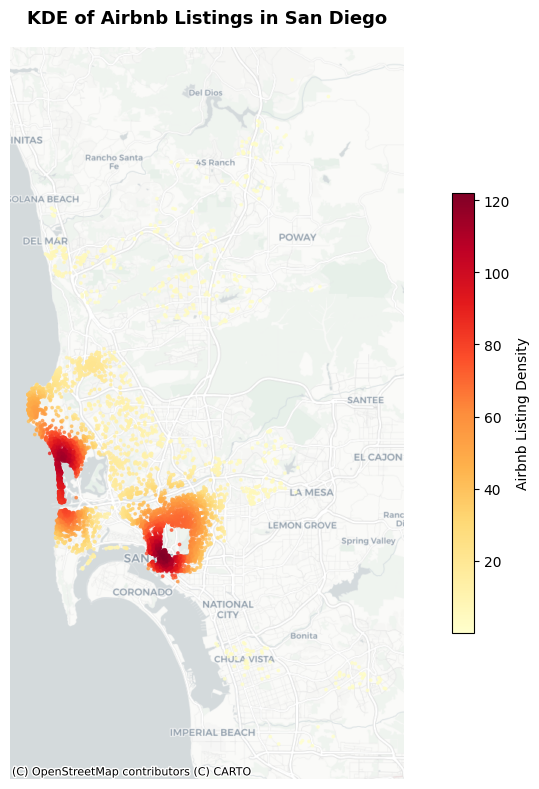

In [27]:
fig, ax = plt.subplots(figsize=(10, 8))

airbnb_wm = airbnb.to_crs(epsg=3857)

airbnb_wm.plot(
    ax=ax,
    column="kde_airbnb",
    cmap="YlOrRd",
    markersize=3,
    alpha=0.7,
    legend=True,
    legend_kwds={"label": "Airbnb Listing Density", "shrink": 0.6}
)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=11)
ax.set_title("KDE of Airbnb Listings in San Diego", fontsize=13, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()

Diese Karte zeigt den KDE der Airbnb listings.

In [14]:
# Imports

import pandas as pd
import numpy as np
import geopandas as gpd

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [15]:
# Load dataset

print("Dataset shape:", airbnb.shape)
print(airbnb.columns)

Dataset shape: (6110, 24)
Index(['accommodates', 'bathrooms', 'bedrooms', 'beds', 'rt_Private_room',
       'rt_Shared_room', 'pg_Condominium', 'pg_House', 'pg_Other',
       'pg_Townhouse', 'price', 'geometry', 'kde_airbnb', 'kde_atm',
       'kde_bank', 'kde_bar', 'kde_bus_station', 'kde_cafe', 'kde_cinema',
       'kde_fast_food', 'kde_parking', 'kde_pub', 'kde_restaurant',
       'kde_theatre'],
      dtype='object')


### Datensatzübersicht

Der Datensatz enthält Informationen zu Airbnb-Listings sowie KDE-basierte räumliche Features für San Diego. Zusätzlich zu klassischen Unterkunftsmerkmalen wie Badezimmern, Schlafzimmern und Betten enthält der Datensatz auch räumliche Dichteindikatoren für nahegelegene Einrichtungen wie Restaurants, Cafés, Krankenhäuser und Verkehrsstationen. Diese Features sollen die Vorhersageleistung der Machine-Learning-Modelle verbessern.

In [16]:
# Define target and input features

target = "price"

basic_features = [
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "rt_Private_room",
    "rt_Shared_room",
    "pg_Condominium",
    "pg_House",
    "pg_Other",
    "pg_Townhouse"
]

model_data = airbnb[basic_features + [target]].dropna()

X = model_data[basic_features]
y = model_data[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (6110, 10)
y shape: (6110,)


### Auswahl der Features

Die Zielvariable der Analyse ist der Airbnb-Preis. Die ausgewählten Eingabevariablen umfassen sowohl klassische Merkmale der Listings als auch kategoriale Eigenschaften der Unterkunft. Diese Variablen stehen häufig im Zusammenhang mit Größe, Qualität und Art der Unterkunft. In diesem Schritt werden zunächst nur die grundlegenden klassischen Features für die ersten Baseline-Modelle verwendet.

In [17]:
# Split data into training and validation sets

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Aufteilung in Trainings- und Validierungsdaten

Der Datensatz wurde mit einer 80/20-Aufteilung in Trainings- und Validierungsdaten unterteilt. Die Trainingsdaten werden verwendet, um die Machine-Learning-Modelle zu trainieren, während die Validierungsdaten zur Bewertung der Vorhersageleistung auf unbekannten Daten dienen. Durch die Verwendung eines festen Random States bleiben die Ergebnisse reproduzierbar.

In [18]:
# Model 1: Trivial baseline
# Predict always the mean price from the training data

mean_price = y_train.mean()

y_pred_trivial = np.full(len(y_val), mean_price)

mae_trivial = mean_absolute_error(y_val, y_pred_trivial)

print("Mean price used for prediction:", round(mean_price, 2))
print("Trivial Baseline MAE:", round(mae_trivial, 2))
print(y.describe())

Mean price used for prediction: 216.57
Trivial Baseline MAE: 150.38
count    6110.000000
mean      215.967594
std       277.549832
min        18.000000
25%        85.000000
50%       139.000000
75%       250.000000
max      4900.000000
Name: price, dtype: float64


<!-- ### Triviales Baseline-Modell

Als Referenzmodell wurde ein triviales Baseline-Modell erstellt, das für alle Beobachtungen den durchschnittlichen Airbnb-Preis vorhersagt. Dieses Modell dient als Vergleichspunkt, um zu bewerten, ob komplexere Machine-Learning-Modelle tatsächlich bessere Vorhersagen liefern. -->

In [19]:
# Linear Regression pipeline
linear_model = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("model", LinearRegression())
])

# Train model
linear_model.fit(X_train, y_train)

# Predictions
linear_preds = linear_model.predict(X_val)

# Metrics
linear_mae = mean_absolute_error(y_val, linear_preds)
linear_rmse = np.sqrt(mean_squared_error(y_val, linear_preds))
linear_r2 = r2_score(y_val, linear_preds)

print("Linear Regression Results")
print("MAE:", round(linear_mae, 2))
print("RMSE:", round(linear_rmse, 2))
print("R²:", round(linear_r2, 3))

Linear Regression Results
MAE: 93.61
RMSE: 175.95
R²: 0.572


### Interpretation der Linear Regression 
Das Modell der linearen Regression erreichte einen Mean Absolute Error (MAE) von ungefähr 94 Dollar. Das bedeutet, dass die vorhergesagten Airbnb-Preise im Durchschnitt etwa 94 Dollar von den tatsächlichen Preisen abweichen. Der R²-Wert von 0.572 zeigt, dass das Modell ungefähr 57 % der Varianz der Airbnb-Preise erklären kann. Insgesamt schneidet das Modell deutlich besser ab als das Baseline-Modell. Dies zeigt, dass die ausgewählten Features relevante Informationen zur Preisvorhersage enthalten. Der relativ hohe RMSE-Wert deutet jedoch darauf hin, dass es weiterhin Listings mit größeren Vorhersagefehlern gibt. Dies kann auf nichtlineare Zusammenhänge oder fehlende räumliche Informationen zurückzuführen sein.

In [20]:
# Decision Tree model

dt_model = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("model", DecisionTreeRegressor(random_state=42))
])

# Train model
dt_model.fit(X_train, y_train)

# Predictions
dt_preds = dt_model.predict(X_val)

# Metrics
dt_mae = mean_absolute_error(y_val, dt_preds)
dt_rmse = np.sqrt(mean_squared_error(y_val, dt_preds))
dt_r2 = r2_score(y_val, dt_preds)

print("Decision Tree Results")
print("MAE:", round(dt_mae, 2))
print("RMSE:", round(dt_rmse, 2))
print("R²:", round(dt_r2, 3))

Decision Tree Results
MAE: 89.0
RMSE: 205.95
R²: 0.414


### Interpretation des Decision Tree Modells

Das Decision Tree Modell erreichte einen niedrigeren MAE-Wert als die lineare Regression, was auf eine bessere durchschnittliche Vorhersagegenauigkeit hinweist. Dies deutet darauf hin, dass das Modell nichtlineare Zusammenhänge zwischen den Features und den Airbnb-Preisen besser erfassen kann. Allerdings ist der R²-Wert geringer als bei der linearen Regression. Dies könnte darauf hindeuten, dass das Modell instabiler ist oder einzelne Ausreißer stärker beeinflusst werden. Decision Trees sind flexibel, können jedoch ohne weitere Optimierung schnell overfitting verursachen.

In [21]:
# Random Forest model

rf_model = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

# Train model
rf_model.fit(X_train, y_train)

# Predictions
rf_preds = rf_model.predict(X_val)

# Metrics
rf_mae = mean_absolute_error(y_val, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_val, rf_preds))
rf_r2 = r2_score(y_val, rf_preds)

print("Random Forest Results")
print("MAE:", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))
print("R²:", round(rf_r2, 3))

Random Forest Results
MAE: 79.92
RMSE: 163.16
R²: 0.632


### Interpretation des Random Forest Modells

Das Random Forest Modell erzielte die beste Gesamtleistung aller getesteten Modelle. Der MAE-Wert ist deutlich niedriger als bei der linearen Regression und beim einzelnen Decision Tree Modell, was auf präzisere Preisvorhersagen hinweist. Auch der R²-Wert ist höher, wodurch ein größerer Anteil der Varianz der Airbnb-Preise erklärt werden kann Random Forest kombiniert viele Decision Trees und reduziert dadurch das Risiko von overfitting. Gleichzeitig können komplexe und nichtlineare Zusammenhänge besser erfasst werden. Die Ergebnisse zeigen, dass ensemble-basierte Methoden besonders gut für die Vorhersage von Airbnb-Preisen geeignet sind.

In [22]:
# Model tuning: Random Forest with different numbers of trees

for n in [50, 100, 200]:

    rf_tuned = Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("model", RandomForestRegressor(
            n_estimators=n,
            random_state=42
        ))
    ])

    rf_tuned.fit(X_train, y_train)

    preds = rf_tuned.predict(X_val)

    mae = mean_absolute_error(y_val, preds)

    print("n_estimators:", n, "→ MAE:", round(mae, 2))


n_estimators: 50 → MAE: 80.05
n_estimators: 100 → MAE: 79.92
n_estimators: 200 → MAE: 79.97


### Hyperparameter-Tuning des Random-Forest-Modells

Zur Optimierung der Modellleistung wurden verschiedene Werte für die Anzahl der Entscheidungsbäume (`n_estimators`) getestet. Die Ergebnisse zeigen, dass die Erhöhung von 50 auf 100 Bäume die Vorhersagegenauigkeit verbessert. Eine weitere Erhöhung auf 200 Bäume führte jedoch zu keiner wesentlichen zusätzlichen Verbesserung. Daher wurde `n_estimators = 100` als sinnvoller Kompromiss zwischen Modellleistung und Rechenaufwand gewählt.

In [23]:
# Check available KDE-based spatial features

kde_features = [
    col for col in airbnb.columns
    if "kde" in col.lower()
]

print("Number of KDE features:", len(kde_features))
print(kde_features)

Number of KDE features: 12
['kde_airbnb', 'kde_atm', 'kde_bank', 'kde_bar', 'kde_bus_station', 'kde_cafe', 'kde_cinema', 'kde_fast_food', 'kde_parking', 'kde_pub', 'kde_restaurant', 'kde_theatre']


### Analyse der KDE-basierten räumlichen Features

Zur Erweiterung des Datensatzes wurden KDE-basierte räumliche Features identifiziert und analysiert. Diese Variablen beschreiben die räumliche Dichte verschiedener Einrichtungen wie Restaurants, Cafés oder Verkehrsstationen in der Umgebung eines Airbnb-Listings. Die Integration dieser räumlichen Informationen ermöglicht es den Machine-Learning-Modellen, neben den Unterkunftsmerkmalen auch den Einfluss der geografischen Lage auf die Preisbildung zu berücksichtigen.

In [24]:
# Compare different input datasets

reduced_features = [
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds"
]

full_features = basic_features + kde_features

def evaluate_random_forest(features):
    data = airbnb[features + [target]].dropna()
    
    X = data[features]
    y = data[target]
    
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    model = RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    
    mae = mean_absolute_error(y_val, preds)
    return mae

mae_reduced = evaluate_random_forest(reduced_features)
mae_full = evaluate_random_forest(full_features)

print("Random Forest MAE with reduced features:", round(mae_reduced, 2))
print("Random Forest MAE with full feature set including KDE:", round(mae_full, 2))

Random Forest MAE with reduced features: 83.96
Random Forest MAE with full feature set including KDE: 76.88


### Interpretation des Vergleichs der Feature-Sets

Das Random-Forest-Modell erzielte einen niedrigeren MAE-Wert, wenn der vollständige Feature-Satz inklusive KDE-basierter räumlicher Features verwendet wurde. Dies zeigt, dass räumliche Informationen und die Dichte nahegelegener Einrichtungen zusätzlichen Vorhersagewert für die Schätzung von Airbnb-Preisen liefern. Im Vergleich zum reduzierten Feature-Satz konnte das Modell mit KDE-Features standortspezifische Effekte besser erfassen.

In [25]:
# Feature importances from Random Forest with full feature set including KDE

rf_importance_model = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

X_full = airbnb[full_features]
y_full = airbnb[target]

rf_importance_model.fit(X_full, y_full)

importances = rf_importance_model.named_steps["model"].feature_importances_

feature_importances = pd.DataFrame({
    "Feature": full_features,
    "Importance": importances
})

feature_importances = feature_importances.sort_values(
    "Importance",
    ascending=False
)

feature_importances

,Feature,Importance
1,bathrooms,0.294653
2,bedrooms,0.209613
0,accommodates,0.056675
8,pg_Other,0.049492
10,kde_airbnb,0.044181
14,kde_bus_station,0.042798
19,kde_pub,0.042622
16,kde_cinema,0.038179
11,kde_atm,0.033459
17,kde_fast_food,0.027442


### Interpretation der Feature Importances

Die Feature-Importance-Analyse zeigt, welche Variablen den größten Einfluss auf die Preisvorhersage des Random-Forest-Modells hatten. Die wichtigsten Merkmale sind bathrooms, bedrooms und accommodates. Das ist plausibel, da diese Variablen direkt die Größe, Ausstattung und Kapazität einer Unterkunft beschreiben. Außerdem erscheinen mehrere KDE-basierte räumliche Features wie kde_airbnb, kde_pub, kde_bus_station und kde_cinema unter den relevanten Variablen. Dies zeigt, dass nicht nur die Eigenschaften der Unterkunft selbst, sondern auch die räumliche Umgebung zur Preisvorhersage beitragen. Insgesamt bestätigt die Analyse, dass die Kombination aus klassischen Listing-Features und räumlichen KDE-Features die Modellinterpretation verbessert.

In [26]:
# Final model comparison

comparison = pd.DataFrame({
    "Model": [
        "Trivial Baseline",
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    
    "MAE": [
        round(mae_trivial, 2),
        round(linear_mae, 2),
        round(dt_mae, 2),
        round(rf_mae, 2)
    ]
})

comparison = comparison.sort_values("MAE")

comparison

,Model,MAE
3,Random Forest,79.92
2,Decision Tree,89.00
1,Linear Regression,93.61
0,Trivial Baseline,150.38


### Finaler Modellvergleich

Der finale Modellvergleich zeigt, dass das Random-Forest-Modell die beste Vorhersageleistung erzielt. Mit einem MAE von 79.92 liegt es deutlich unter dem Fehler des Trivial-Baseline-Modells. Auch im Vergleich zur linearen Regression und zum einzelnen Decision Tree Modell schneidet Random Forest besser ab. Dies zeigt, dass ensemble-basierte Modelle komplexe und nichtlineare Zusammenhänge in den Airbnb-Daten besser erfassen können. Insgesamt ist Random Forest daher das geeignetste Modell für die Preisvorhersage in diesem Case Study.